<a href="https://colab.research.google.com/github/LucasFaleirosMoreira/university-studies/blob/main/IA_23_08_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INTEGRANTES DO GRUPO**

GABRIEL LEDOLINI DE MORAIS \\
JOÃO VITOR FERREIRA \\
LUCAS FALEIROS MOREIRA \\
MURILO GURZONI MANZANARES \\





In [ ]:
!pip -q install tableone

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.6 MB/s eta 0:00:00


In [ ]:
#Importação das bibliotecas utilizadas na analise de dados
import pandas as pd
import numpy as np
import seaborn as sbn
import matplotlib.pyplot as mt
from tableone import TableOne

In [ ]:
#importação do csv para um dataframe
df_dados = pd.read_csv("/conjunto_de_dados.csv", encoding="ISO-8859-1", sep=";")

In [ ]:
#amostragem dos dados do dataframe
df_dados.head()

,NOME,DATA LANÇAMENTO,AUTOR,EDITORA,EDIÇÃO,GENÊRO,CLASSIFICAÇÃO INDICATIVA,NÚMERO DE ESTOQUE,ALUGADOS NO MÊS,VALOR ALUGUEL,Unnamed: 10
0,As 7 Cabeças,17/03/1979,Pedro Bandeira,Salamandra,2ª,Suspense,16,24,22,"R$ 10,98",NaN
1,Lágrima de um Poeta,06/08/1896,Miguel Silvana,Poppis,5ª,Drama,10,8,3,"R$ 9,99",NaN
2,A Vingança de Eddie Hoody,07/06/2001,Olivier Clark,Karilio,1ª,Suspense,12,17,9,"R$ 15,67",NaN
3,Os Fenômenos Estranhos de Pedro,09/12/1993,Yuri Souza,Salamandra,2ª,Ficção Científica,L,35,28,"R$ 20,50",NaN
4,A Vida e a luz da Morte,28/04/1921,Marie P. F. Medelin,Brotes,4ª,Drama,14,15,6,"R$ 55,19",NaN


In [ ]:
#Shape para visualizar a estrutura do dataframe (quantas linhas e colunas)
df_dados.shape

(20, 11)

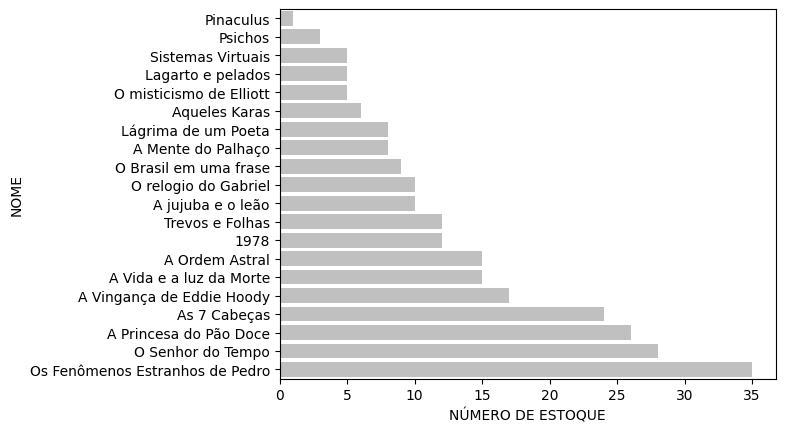

In [ ]:
#definindo uma variavel para ordenar o gráfico
ordem = df_dados.sort_values(by="NÚMERO DE ESTOQUE", ascending=True)["NOME"]

#iniciando um grafico de barra com o dataframe df_dados baseado nas colunas NOME e NUMERO DE ESTOQUE
sbn.barplot(data=df_dados, y="NOME", x="NÚMERO DE ESTOQUE", color="silver", order=ordem)

mt.show()

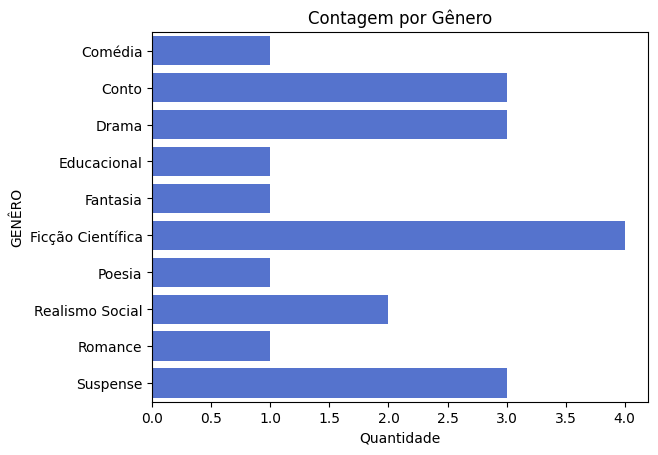

In [ ]:
#ordenando o gráfico por gênero
ordem_g = df_dados.sort_values(by="GENÊRO", ascending=True)["GENÊRO"]

#fazendo um gráfico de gênero com sua quantidade
sbn.countplot(data=df_dados, y='GENÊRO', order=ordem_g, color="royalblue")
mt.xlabel("Quantidade")
mt.title("Contagem por Gênero")
mt.show()

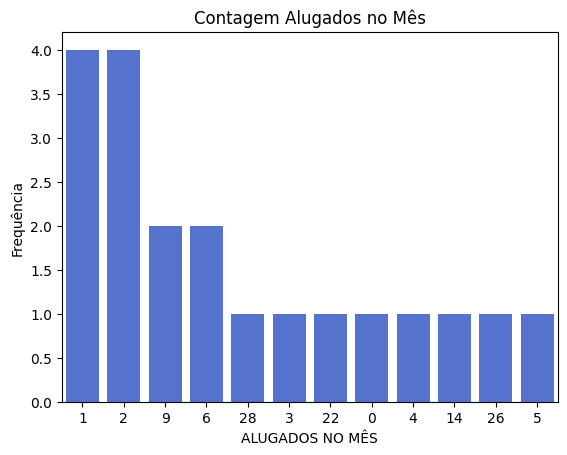

In [ ]:
#ordenando o gráfico por frequencia do alugados no mes
ordem = df_dados['ALUGADOS NO MÊS'].value_counts().sort_values(ascending=False).index

# Gráfico de barras do alugados no mes
sbn.countplot(data=df_dados, x='ALUGADOS NO MÊS', order=ordem, color="royalblue")
mt.title("Contagem Alugados no Mês")
mt.ylabel("Frequência")
mt.show()

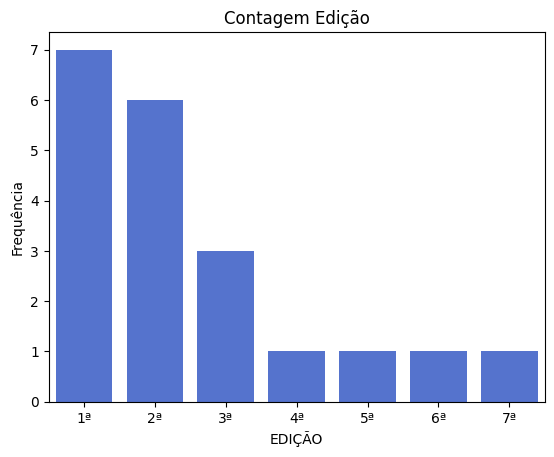

In [ ]:
#ordenando o gráfico por frequencia da edição
ordem = df_dados.sort_values(by="EDIÇÃO", ascending=True)["EDIÇÃO"]

# Gráfico de barras da frequencia de cada ediçao
sbn.countplot(data=df_dados, x='EDIÇÃO', order=ordem, color="royalblue")
mt.ylabel("Frequência")
mt.title("Contagem Edição")
mt.show()

In [ ]:
#definindo as colunas que serão utilizadas no tableOne
colunas = ['NÚMERO DE ESTOQUE', 'VALOR ALUGUEL', 'ALUGADOS NO MÊS']

#definindo o grupo
grupo = 'GENÊRO'

#criando o tableone
tabela = TableOne(data=df_dados, columns=colunas, groupby=grupo, pval=True)
print(tabela)

                                       Grouped by GENÊRO                                                                                                                                                    
                                                 Missing     Overall    Comédia        Conto       Drama Educacional   Fantasia Ficção Científica      Poesia Realismo Social    Romance    Suspense P-Value
n                                                                 20          1            3           3           1          1                 4           1               2          1           3        
NÚMERO DE ESTOQUE, mean (SD)                           0  12.7 (9.2)  6.0 (0.0)   15.3 (9.2)  11.7 (3.5)   5.0 (0.0)  1.0 (0.0)       14.5 (14.6)  12.0 (0.0)       8.5 (0.7)  5.0 (0.0)  23.0 (5.6)   0.590
VALOR ALUGUEL, n (%)         R$ 10,98                       2 (10.0)    0 (0.0)      0 (0.0)     0 (0.0)     0 (0.0)    0 (0.0)           0 (0.0)   1 (100.0)         0 (0.0)    0 (